# **Boosting Techniques - Assignment (Practicales)**

# Q14  Train an AdaBoost Classifier on a sample dataset and print model accuracy

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load dataset
iris = load_iris()
X, y = iris.data, iris.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Create an AdaBoost classifier
adaboost = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=50, random_state=2)

# Train the model
adaboost.fit(X_train, y_train)

# Make predictions
y_pred = adaboost.predict(X_test)

# Calculate and print model accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")


Model Accuracy: 0.97


# Q15  Train an AdaBoost Regressor and evaluate performance using Mean Absolute Error (MAE)

Mean Absolute Error (MAE): 0.2697


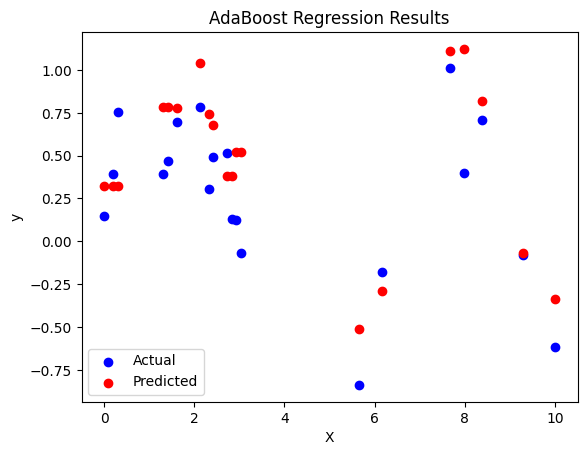

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error

# Generate synthetic data
np.random.seed(42)
X = np.linspace(0, 10, 100).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(scale=0.3, size=X.shape[0])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Initialize AdaBoost Regressor with DecisionTreeRegressor as base estimator
base_estimator = DecisionTreeRegressor(max_depth=4)
adaboost_regressor = AdaBoostRegressor(estimator=base_estimator, n_estimators=50, random_state=2)

# Train the model
adaboost_regressor.fit(X_train, y_train)

# Make predictions
y_pred = adaboost_regressor.predict(X_test)

# Evaluate performance using MAE
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): {mae:.4f}")

# Plot results
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.scatter(X_test, y_pred, color='red', label='Predicted')
plt.legend()
plt.xlabel('X')
plt.ylabel('y')
plt.title('AdaBoost Regression Results')
plt.show()

# Q16  Train a Gradient Boosting Classifier on the Breast Cancer dataset and print feature importance

                    Feature  Importance
7       mean concave points    0.450528
27     worst concave points    0.240103
20             worst radius    0.075589
22          worst perimeter    0.051408
21            worst texture    0.039886
23               worst area    0.038245
1              mean texture    0.027805
26          worst concavity    0.018725
16          concavity error    0.013068
13               area error    0.008415
10             radius error    0.006870
24         worst smoothness    0.004811
19  fractal dimension error    0.004224
11            texture error    0.003604
5          mean compactness    0.002996
15        compactness error    0.002511
4           mean smoothness    0.002467
17     concave points error    0.002038
28           worst symmetry    0.001478
12          perimeter error    0.001157
6            mean concavity    0.000922
18           symmetry error    0.000703
14         smoothness error    0.000556
8             mean symmetry    0.000520


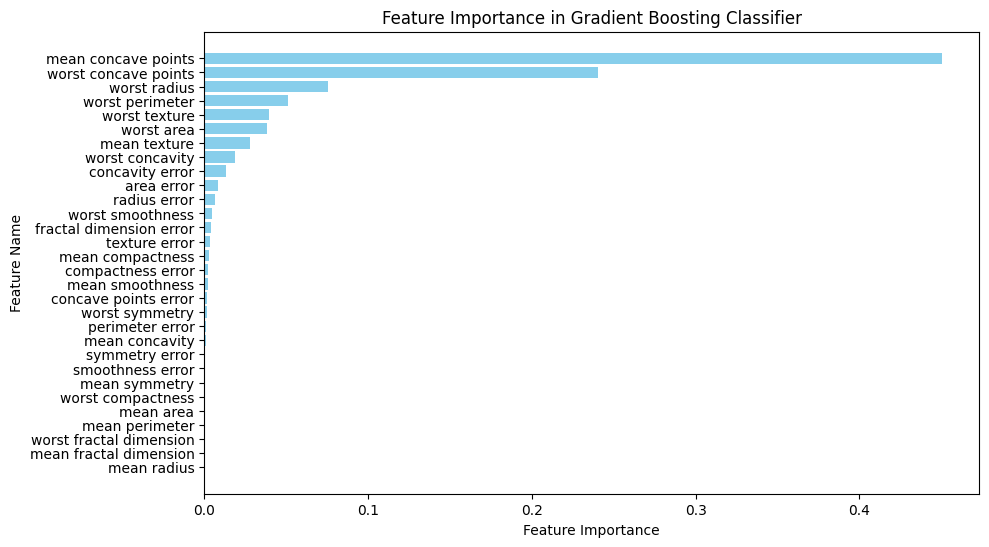

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the breast cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Initialize and train the Gradient Boosting Classifier
clf = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=2)
clf.fit(X_train, y_train)

# Get feature importance
feature_importance = clf.feature_importances_
feature_names = data.feature_names

# Create a DataFrame to display feature importance
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Print feature importance
print(importance_df)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Feature Importance')
plt.ylabel('Feature Name')
plt.title('Feature Importance in Gradient Boosting Classifier')
plt.gca().invert_yaxis()
plt.show()

# Q17  Train a Gradient Boosting Regressor and evaluate using R-Squared Score italicized text

In [ ]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score


# Generate synthetic regression data
X, y = make_regression(n_samples=1000, n_features=10, noise=0.2, random_state=2)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Initialize and train the Gradient Boosting Regressor
model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=2)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate using R-Squared score
r2 = r2_score(y_test, y_pred)
print(f'R-Squared Score: {r2:.4f}')


R-Squared Score: 0.8994


# Q18 Train an XGBoost Classifier on a dataset and compare accuracy with Gradient Boosting

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
from warnings import filterwarnings
filterwarnings('ignore')

# Load dataset
data = load_iris()
X = data.data
y = data.target

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Train Gradient Boosting Classifier
gb_clf = GradientBoostingClassifier()
gb_clf.fit(X_train, y_train)
y_pred_gb = gb_clf.predict(X_test)
accuracy_gb = accuracy_score(y_test, y_pred_gb)

# Train XGBoost Classifier
xgb_clf = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgb_clf.fit(X_train, y_train)
y_pred_xgb = xgb_clf.predict(X_test)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)

# Compare accuracy
print(f'Gradient Boosting Accuracy: {accuracy_gb:.4f}')
print(f'XGBoost Accuracy: {accuracy_xgb:.4f}')


Gradient Boosting Accuracy: 0.9333
XGBoost Accuracy: 0.9667


# Q19 Train a CatBoost Classifier and evaluate using F1-Score

In [ ]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 6.1 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.datasets import make_classification

# Generate a synthetic dataset
X, y = make_classification(n_samples=1000, n_features=10, random_state=2)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Initialize and train the CatBoostClassifier
model = CatBoostClassifier(iterations=100, depth=6, learning_rate=0.1, verbose=0)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Compute the F1-score
f1 = f1_score(y_test, y_pred)

print(f"F1-Score: {f1:.4f}")

F1-Score: 0.8571


# Q20  Train an XGBoost Regressor and evaluate using Mean Squared Error (MSE)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import xgboost as xgb

# Generate synthetic dataset
np.random.seed(42)
X = np.random.rand(1000, 5)  # 1000 samples, 5 features
y = X @ np.array([1.5, -2.0, 3.0, 0.5, -1.0]) + np.random.normal(0, 0.1, 1000)  # Linear relation with noise

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize XGBoost Regressor
xgb_regressor = xgb.XGBRegressor(objective="reg:squarederror", n_estimators=100, learning_rate=0.1)

# Train the model
xgb_regressor.fit(X_train, y_train)

# Predict on test set
y_pred = xgb_regressor.predict(X_test)

# Compute Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.4f}")

Mean Squared Error: 0.0527


# Q21  Train an AdaBoost Classifier and visualize feature importance

Test Accuracy: 0.8800


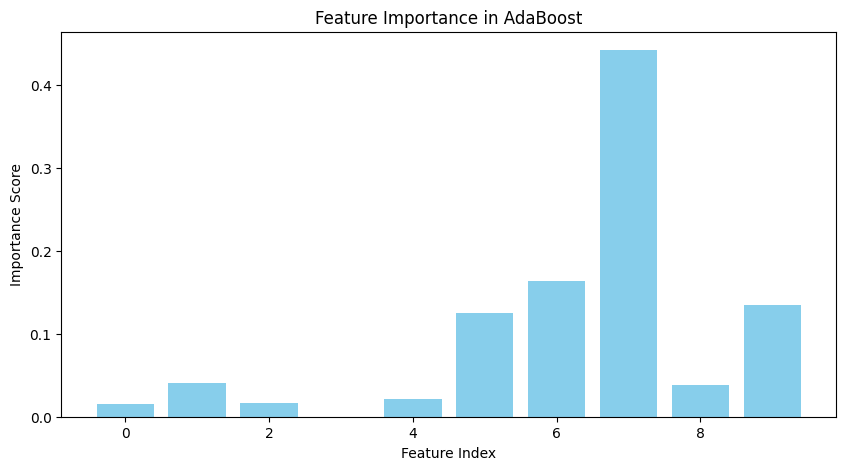

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Generate synthetic dataset
X, y = make_classification(n_samples=1000, n_features=10, random_state=2)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Train AdaBoost Classifier
base_estimator = DecisionTreeClassifier(max_depth=1)  # Weak learner
adaboost = AdaBoostClassifier(estimator=base_estimator, n_estimators=50, random_state=2)
adaboost.fit(X_train, y_train)

# Evaluate model
y_pred = adaboost.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

# Feature importance visualization
feature_importances = adaboost.feature_importances_
plt.figure(figsize=(10, 5))
plt.bar(range(len(feature_importances)), feature_importances, color='skyblue')
plt.xlabel("Feature Index")
plt.ylabel("Importance Score")
plt.title("Feature Importance in AdaBoost")
plt.show()

# Q22  Train a Gradient Boosting Regressor and plot learning curves

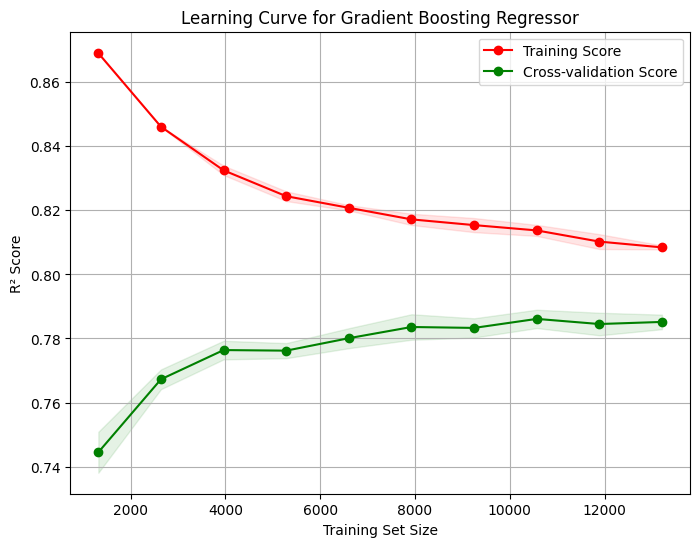

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve, train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler

# Load dataset
data = fetch_california_housing()
X, y = data.data, data.target

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize Gradient Boosting Regressor
gbr = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Compute learning curve
train_sizes, train_scores, test_scores = learning_curve(gbr, X_train, y_train, cv=5, scoring='r2', n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10))

# Calculate mean and standard deviation for train and test scores
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot learning curves
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, 'o-', color='r', label='Training Score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
plt.plot(train_sizes, test_mean, 'o-', color='g', label='Cross-validation Score')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='g')
plt.xlabel("Training Set Size")
plt.ylabel("R² Score")
plt.title("Learning Curve for Gradient Boosting Regressor")
plt.legend()
plt.grid()
plt.show()


# Q23 Train an XGBoost Classifier and visualize feature importance

Accuracy: 0.96


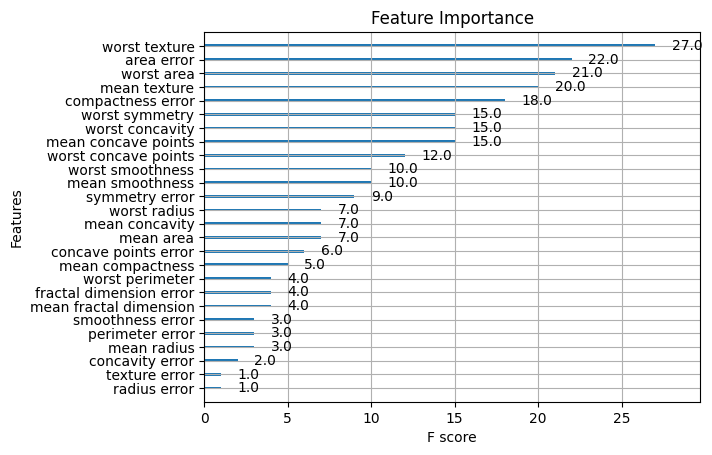

In [ ]:
import xgboost as xgb
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train XGBoost classifier
model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Plot feature importance
xgb.plot_importance(model)
plt.title("Feature Importance")
plt.show()


# Q24 Train a CatBoost Classifier and plot the confusion matrix

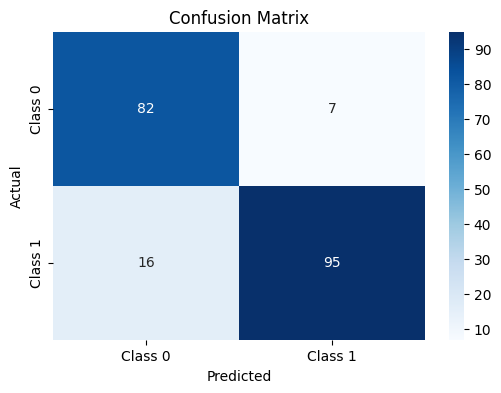

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix
from catboost import CatBoostClassifier

# Generate synthetic dataset
X, y = make_classification(n_samples=1000, n_features=10, n_classes=2, random_state=42)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train CatBoost classifier
model = CatBoostClassifier(iterations=100, depth=6, learning_rate=0.1, verbose=0)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Class 0", "Class 1"], yticklabels=["Class 0", "Class 1"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Q25  Train an AdaBoost Classifier with different numbers of estimators and compare accuracy

In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
#Load the Iris dataset
data = load_iris()
X = data.data
y = data.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2)

# Define the number of estimators to test
n_estimators_list = [10, 50, 100, 200]

# Dictionary to store accuracy scores
accuracy_scores = {}

# Train AdaBoost classifiers with different numbers of estimators
for n_estimators in n_estimators_list:
    # Initialize the base classifier (usually a Decision Tree)
    base_classifier = DecisionTreeClassifier(max_depth=1)

    # Initialize the AdaBoost classifier
    adaboost_clf = AdaBoostClassifier(base_classifier, n_estimators=n_estimators, random_state=2)
# Train the classifier
    adaboost_clf.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = adaboost_clf.predict(X_test)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)

    # Store the accuracy score
    accuracy_scores[n_estimators] = accuracy

    # Print the accuracy scores for each number of estimators
for n_estimators, accuracy in accuracy_scores.items():
    print(f"Number of Estimators: {n_estimators}, Accuracy: {accuracy:.4f}")

Number of Estimators: 10, Accuracy: 0.9556
Number of Estimators: 50, Accuracy: 0.9778
Number of Estimators: 100, Accuracy: 0.9778
Number of Estimators: 200, Accuracy: 0.9778


# Q26 Train a Gradient Boosting Classifier and visualize the ROC curve

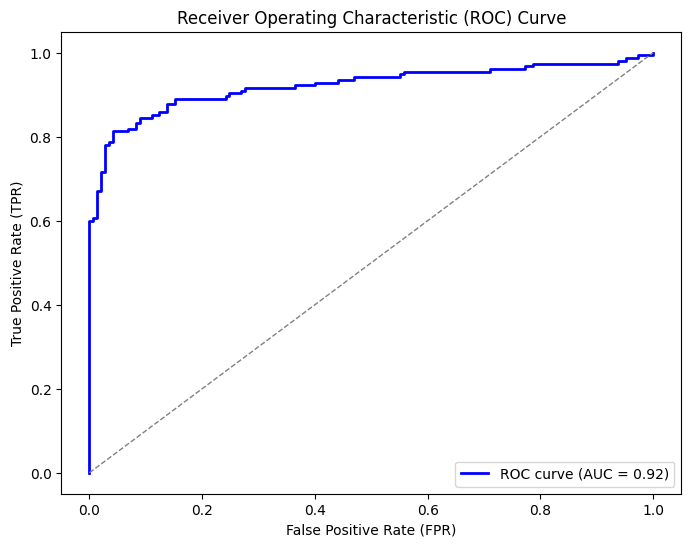

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_curve, auc

# Generate a synthetic dataset
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=2)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2)

# Initialize the Gradient Boosting Classifier
gb_clf = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=2)

# Train the model
gb_clf.fit(X_train, y_train)

# Predict probabilities for the test set
y_probs = gb_clf.predict_proba(X_test)[:, 1]

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# Q27  Train an XGBoost Regressor and tune the learning rate using GridSearchCV

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

# Generate sample data
np.random.seed(42)
X = np.random.rand(100, 5)
y = 3 * X[:, 0] + 2 * X[:, 1] + np.random.randn(100) * 0.1  # y is a function of X with some noise

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Define the XGBoost Regressor
xgb = XGBRegressor(objective='reg:squarederror', random_state=2)

# Define the parameter grid for learning rate tuning
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3]  # Different values to tune
}

# Perform Grid Search with Cross Validation
grid_search = GridSearchCV(xgb, param_grid, scoring='neg_mean_squared_error', cv=5, verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best learning rate
best_learning_rate = grid_search.best_params_['learning_rate']
print(f"Best Learning Rate: {best_learning_rate}")

# Train final model with best learning rate
best_xgb = XGBRegressor(objective='reg:squarederror', learning_rate=best_learning_rate, random_state=2)
best_xgb.fit(X_train, y_train)

# Evaluate the model
y_pred = best_xgb.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Test MSE: {mse}")

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best Learning Rate: 0.2
Test MSE: 0.05464536888639645


## Q28  Train a CatBoost Classifier on an imbalanced dataset and compare performance with class weighting

In [ ]:
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier,Pool
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Step 1: Generate an imbalanced dataset
X, y = make_classification(n_samples=5000, n_features=20, n_classes=2, weights=[0.9, 0.1], random_state=2)

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Step 2: Train a CatBoost Classifier without class weights
model_no_weight = CatBoostClassifier(iterations=500, learning_rate=0.1, depth=6, verbose=0, random_seed=2)
model_no_weight.fit(X_train, y_train)

# Step 3: Train a CatBoost Classifier with class weighting
class_weights = {0: 1, 1: 9}  # Inverse of class frequencies
model_with_weight = CatBoostClassifier(iterations=500, learning_rate=0.1, depth=6, class_weights=class_weights, verbose=0, random_seed=2)
model_with_weight.fit(X_train, y_train)

# Step 4: Evaluate both models
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "AUC-ROC": roc_auc_score(y_test, y_prob)
    }
    return metrics

metrics_no_weight = evaluate_model(model_no_weight, X_test, y_test)
metrics_with_weight = evaluate_model(model_with_weight, X_test, y_test)

# Display the results
df_results = pd.DataFrame([metrics_no_weight, metrics_with_weight], index=["No Class Weight", "With Class Weight"])
print(df_results)

                   Accuracy  Precision    Recall  F1-score   AUC-ROC
No Class Weight       0.941   0.794872  0.590476  0.677596  0.943549
With Class Weight     0.934   0.693069  0.666667  0.679612  0.947869


# Q29  Train an AdaBoost Classifier and analyze the effect of different learning rates

Learning Rate: 0.001, Accuracy: 0.7333
Learning Rate: 0.01, Accuracy: 0.9333
Learning Rate: 0.1, Accuracy: 0.9333
Learning Rate: 0.5, Accuracy: 0.9667
Learning Rate: 1, Accuracy: 0.9667
Learning Rate: 2, Accuracy: 0.9000


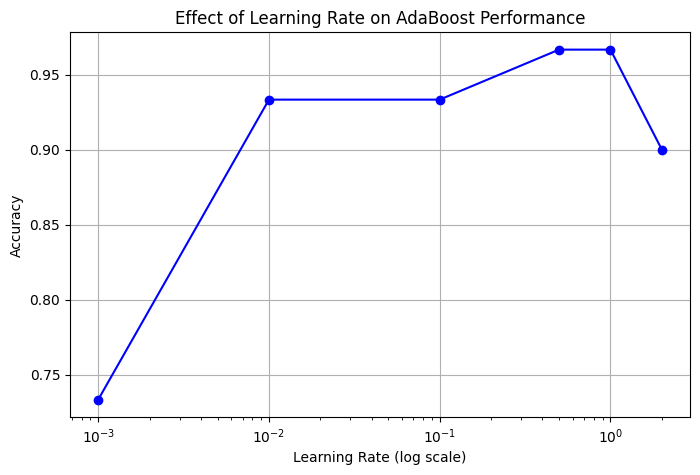

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score

# Load dataset
iris = load_iris()
X, y = iris.data, iris.target

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Define different learning rates
learning_rates = [0.001, 0.01, 0.1, 0.5, 1, 2]
accuracies = []

# Train AdaBoost classifier with different learning rates
for lr in learning_rates:
    model = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                               n_estimators=50, learning_rate=lr, random_state=2)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f'Learning Rate: {lr}, Accuracy: {acc:.4f}')

# Plot the results
plt.figure(figsize=(8, 5))
plt.plot(learning_rates, accuracies, marker='o', linestyle='-', color='b')
plt.xscale('log')
plt.xlabel('Learning Rate (log scale)')
plt.ylabel('Accuracy')
plt.title('Effect of Learning Rate on AdaBoost Performance')
plt.grid(True)
plt.show()


# Q30 Train an XGBoost Classifier for multi-class classification and evaluate using log-loss

In [ ]:
import numpy as np
import xgboost as xgb
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss
from sklearn.preprocessing import LabelEncoder
from sklearn.datasets import make_classification
from warnings import filterwarnings
filterwarnings('ignore')
# Step 1: Generate synthetic dataset
X, y = make_classification(n_samples=1000, n_features=20, n_classes=3, n_informative=10, random_state=2)

# Step 2: Encode labels (XGBoost requires numeric labels)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Step 3: Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=2)

# Step 4: Train XGBoost classifier
xgb_clf = xgb.XGBClassifier(objective="multi:softprob", num_class=3, eval_metric="mlogloss", use_label_encoder=False)
xgb_clf.fit(X_train, y_train)

# Step 5: Predict probabilities
y_pred_proba = xgb_clf.predict_proba(X_test)

# Step 6: Compute Log-Loss
loss = log_loss(y_test, y_pred_proba)
print(f"Log-Loss: {loss:.4f}")

Log-Loss: 0.4013
